# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. The data set I choose is the Census Data file.
2. My label is income_binary. I am predicting the avg salary and representing them in a binary classification.
3. The features I plan to use are occupation, hours-per-week, education-num, workclass, martial-status, and age. I may change this as I'm exploring my data.
4. This problem matter because the CDFI wants to know the threshold income of each individuals to determine eligibility of their programs in a timely matter than before.The CDFI could use a model that predicts the income label based on the client's features and then classify their income as binary(0s and 1s) if their income surpasses the threshold.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [3]:
#I plan to use Decision Trees due to the model effective use for numerical and categorial features. The label is also a categorical column, which decisions trees works best. 

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

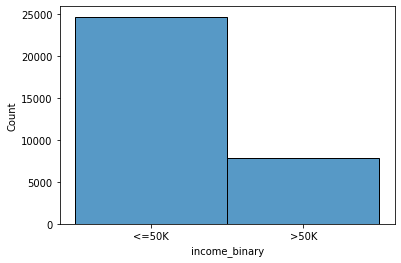

In [4]:
sns.histplot(data=df["income_binary"])
plt.show()

In [5]:
#Seems to be a significant imbalance between the label

In [6]:
df["income_binary"]

0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income_binary, Length: 32561, dtype: object

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

In [7]:
features_to_remove = ["fnlwgt", "relationship", "education"]
df = df.drop(columns=features_to_remove)


In [8]:
#Removes redundant features

In [9]:
df.isna().sum()


age                162
workclass         1836
education-num        0
marital-status       0
occupation        1843
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [10]:
nan_count = np.sum(df.isnull(), axis = 0)
nan_detected = nan_count != 0
print(nan_detected)

age                True
workclass          True
education-num     False
marital-status    False
occupation         True
race              False
sex_selfID        False
capital-gain      False
capital-loss      False
hours-per-week     True
native-country     True
income_binary     False
dtype: bool


In [11]:
# Searches for NaN values and will prepare them for replacing the NaN values with mean values. Used describe to get statistics of the dataset

In [12]:
df.describe(include='all')

,age,workclass,education-num,marital-status,occupation,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
count,32399.000000,30725,32561.000000,32561,30718,32561,32561,32561.000000,32561.000000,32236.000000,31978,32561
unique,NaN,8,NaN,7,14,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,Married-civ-spouse,Prof-specialty,White,Non-Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,14976,4140,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.589216,NaN,10.080679,NaN,NaN,NaN,NaN,615.907773,87.303830,40.450428,NaN,NaN
std,13.647862,NaN,2.572720,NaN,NaN,NaN,NaN,2420.191974,402.960219,12.353748,NaN,NaN
min,17.000000,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,9.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,10.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,12.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [13]:
df.dtypes
is_int_or_float = (df.dtypes == 'int64') | (df.dtypes == 'float64')
to_impute = nan_detected & is_int_or_float
print(to_impute)

age                True
workclass         False
education-num     False
marital-status    False
occupation        False
race              False
sex_selfID        False
capital-gain      False
capital-loss      False
hours-per-week     True
native-country    False
income_binary     False
dtype: bool


In [14]:
#Finding columns that have NaN values and int or float data types to replace. For categorical columns, they will be one-hot-encoded.

In [15]:
df.columns[to_impute]

Index(['age', 'hours-per-week'], dtype='object')

In [16]:
#Below are scatterplots of columns that have the type int or float to identify outliers

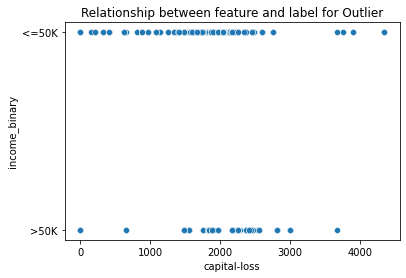

In [17]:
sns.scatterplot(x='capital-loss', y='income_binary', data=df)
plt.title('Relationship between feature and label for Outlier')
plt.show()

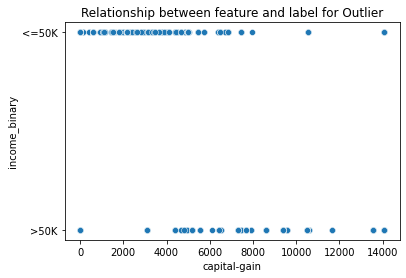

In [18]:
sns.scatterplot(x='capital-gain', y='income_binary', data=df)
plt.title('Relationship between feature and label for Outlier')
plt.show()

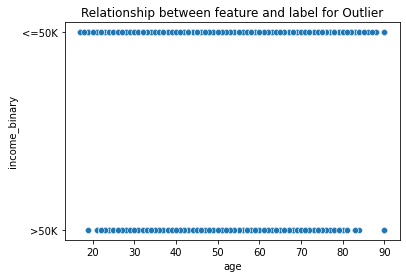

In [19]:
sns.scatterplot(x='age', y='income_binary', data=df)
plt.title('Relationship between feature and label for Outlier')
plt.show()

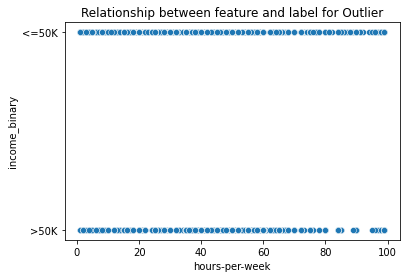

In [20]:
sns.scatterplot(x='hours-per-week', y='income_binary', data=df)
plt.title('Relationship between feature and label for Outlier')
plt.show()

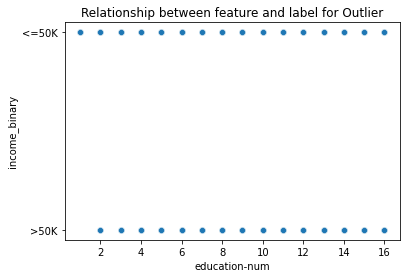

In [21]:
sns.scatterplot(x='education-num', y='income_binary', data=df)
plt.title('Relationship between feature and label for Outlier')
plt.show()

I removed columns "fnlwgt", "relationship", "education" to reduce redundancy and improve my predictive model. When I checked the null values, columns like age, workclass, occupation, hours-per-week, and native-country have a signficant amount of NaN values. I plan to replace the NaNs with the mean. I used scatterplot to identify outliers and the columns with float or int have a few outliers especially, capital-gain and capital-loss. Since I am using Decision Trees, winsorizing those features aren't needed since the label is not numerical. However, I will need to convert the label into binary for effective model. There was a significant class imbalance when the income is less than 50k as incomes less than 50k are much higher than incomes that are greater than 50k. There is a major imbalance and I will handle that by creating my decision tree model and set the class_weight to 'balanced'. I plan to handle the categorical features and one-hot-encode them to prepare for my decision tree model. 

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. The features selected such as Race, Native-country, or Sex could have potential biases towards underrepresented groups or favor a group more than others when making an accuracy prediction. The CDFI was the one who collected the data through the U.S. Census demographic and employment records. Those features contains group whose presence are more dominiant than other groups. The features that could serve as proxies for protected characteristics are features like Sex or native-country. Native-country feature majorly consisted of United States. 
2. Who could be harmed by a model are the minority groups based on Race, Gender, or location. For example a minority native country in a dataset like Canada when placed in a United States dominant column could have the model favorable and based it's prediction on the United States over a less present native country like Canada or Africa. 

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [22]:
#Only two columns are int or floats that have NaN values, I will replace them with mean values.

In [23]:
to_impute_selected = ['age', 'hours-per-week']
for columns in to_impute_selected:
    df[columns + "_na"] = df[columns].isnull()
df.head()

,age,workclass,education-num,marital-status,occupation,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary,age_na,hours-per-week_na
0,39.0,State-gov,13,Never-married,Adm-clerical,White,Non-Female,2174,0,40.0,United-States,<=50K,False,False
1,50.0,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,White,Non-Female,0,0,13.0,United-States,<=50K,False,False
2,38.0,Private,9,Divorced,Handlers-cleaners,White,Non-Female,0,0,40.0,United-States,<=50K,False,False
3,53.0,Private,7,Married-civ-spouse,Handlers-cleaners,Black,Non-Female,0,0,40.0,United-States,<=50K,False,False
4,28.0,Private,13,Married-civ-spouse,Prof-specialty,Black,Female,0,0,40.0,Cuba,<=50K,False,False


In [24]:
for columns in to_impute_selected:
    mean_val = df[columns].mean()
    df[columns].fillna(value=mean_val, inplace=True)

In [25]:
#Checks for no more NaN values 

In [26]:
for colname in to_impute_selected:
    print("{} missing values count :{}".format(colname, np.sum(df[colname].isnull(), axis = 0)))

age missing values count :0
hours-per-week missing values count :0


In [27]:
#Encodes the label into binary and one-hot-encode categorical columns to prepare for Decision Tree Model 

In [28]:
encode = LabelEncoder()

In [29]:
df['income_binary'] = encode.fit_transform(df['income_binary'])
df = pd.get_dummies(df, drop_first=True)

In [30]:
df.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,age_na,hours-per-week_na,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,13,2174,0,40.0,0,False,False,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,13,0,0,13.0,0,False,False,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38.0,9,0,0,40.0,0,False,False,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,7,0,0,40.0,0,False,False,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,13,0,0,40.0,0,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
#Now the model is ready to be trained and evaluate after the one-hot-encoding

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I replaced missing values with the mean because this will ensure the model will have an accurate prediction and prevent the NaN values from alternating the model's predictions. I also have to encode the label into binary because decision tree models is a classification model and to ensure the model will predict well, I need to convert the label into 0s and 1s for easier time evaluation. I also have to one-hot-encode columns that are categorical as the model cannot evaulate those columns if they are text. Finally, I removed the some features like education because this dataset already have education-num column and it can make a correlated decision based on that and education is not needed. There is no need for scaling nor winsorization for decision tree because decision trees cannot handle numerical values and the label is also a classification label and not a numeric one.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [32]:
# Create labeled examples from the dataset
y = df['income_binary']
X = df.drop(columns='income_binary')

In [33]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

In [34]:
# Train, test and evaluate your model
model_default = DecisionTreeClassifier(criterion='entropy', max_depth=5, class_weight='balanced', min_samples_leaf=1)
model_default.fit(X_train, y_train)
class_label_predictions_default = model_default.predict(X_test)
acc_score_default = accuracy_score(y_test, class_label_predictions_default)
f1_score_default = f1_score(y_test, class_label_predictions_default, average='binary')
print(f'Accuracy Score Default: {acc_score_default}')
print(f'F1 Score Default: {f1_score_default}')


Accuracy Score Default: 0.7814515303511107
F1 Score Default: 0.6438698915763136


In [35]:
c_m = confusion_matrix(y_test, class_label_predictions_default, labels=[True, False])
pd.DataFrame(c_m,columns=['Predicted: <=50K', 'Predicted: >50K'],index=['Actual: <=50K', 'Actual: >50K'])

,Predicted: <=50K,Predicted: >50K
Actual: <=50K,1930,370
Actual: >50K,1765,5704


In [36]:
#Based on the accuracy score and F1 Score, the model accurately predicts the individuals whose income is greater than 50k. 

In [37]:
#In the confusion matrix, the Decision Tree model is mostly accurate in predicting income above 50k by a large margin through true positive. The model does predict individuals whose income is below 50k. Based on the high TP from CM, this accurately solve the business problem which helps Equilend to correcly predict incomes that are above 50K. 

In [38]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
cs=[10**i for i in range(-5,5)]
param_grid = {'max_depth': cs}

model = DecisionTreeClassifier(criterion='entropy', max_depth=5,class_weight='balanced', min_samples_leaf=1)

grid = GridSearchCV(model, param_grid, cv=5)

grid_search = grid.fit(X_train, y_train)
print('Done')

Done


In [39]:
best_depth = grid_search.best_estimator_.max_depth

best_depth

1000

In [40]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
model_best = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, class_weight='balanced', min_samples_leaf=1)
model_best.fit(X_train, y_train)
class_label_predictions_best = model_best.predict(X_test)
acc_score_best = accuracy_score(y_test, class_label_predictions_best)
f1_score_best = f1_score(y_test, class_label_predictions_best, average='binary')
print(f'Accuracy Score Best: {acc_score_best}')
print(f'F1 Score Best: {f1_score_best}')

Accuracy Score Best: 0.8098065308629337
F1 Score Best: 0.6153209109730848


In [41]:
#After finding the best hyperparmeters(depth for decision trees) through Cross Search, the accuracy score went up from 78% to 81% but F1 Score went down from 64% to 62%. This could mean the model priortized accuracy over F1 Score. To improve this, perhaps lowering the max_depth and increasing the min_samples_leaf to find the highest F1 score possible. 

In [42]:
c_m2 = confusion_matrix(y_test, class_label_predictions_best, labels=[True, False])
pd.DataFrame(c_m2,columns=['Predicted: <=50K', 'Predicted: >50K'],index=['Actual: <=50K', 'Actual: >50K'])

,Predicted: <=50K,Predicted: >50K
Actual: <=50K,1486,814
Actual: >50K,1044,6425


In [43]:
#Much higher TP and an improved TN. The false positives and negatives have decreased, which means the model improved at predicting incomes correctly.

In [44]:
# Interpret your model's outputs 
importances = pd.Series(model_best.feature_importances_, index=X.columns)
top_5_features = importances.sort_values(ascending=False).head(5)
print(top_5_features)

marital-status_Married-civ-spouse    0.237879
age                                  0.186923
education-num                        0.132974
capital-gain                         0.104331
hours-per-week                       0.093539
dtype: float64


In [45]:
# The top 5 features are marital-status_Married-civ-spouse, age, education-num, capital-gain, and hours-per-week. There seems to be a high correlation with married couples, age, and their education in terms of individuals whose incomes are higher than 50K.

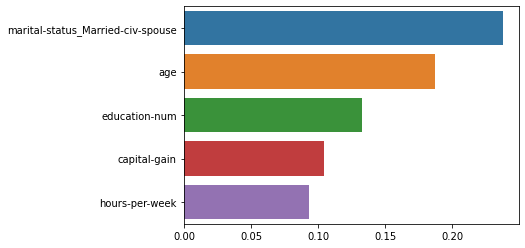

In [46]:
sns.barplot(x=top_5_features.values, y=top_5_features.index)
plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I chose Decision Trees due to the model effective use for numerical and categorial features. The label is also a categorical column, which decisions trees works best. The ML problem was to predict and classify individual's incomes that exceed 50K. The other models(KNN neighbors and logistic/linear regression) don't work well with categorical ML problems.
2. I learned through the model selection process that my accuracy improved from 79% to 81% after finding the best hyperparamters. However my F1 Score went down from 64% to 62%. Next time, I seek to decrease the depth and increase the min_samples_leaf in seeking a higher F1 Score. The model did get better at predicting the true positives and negatives.
3. As stated before, the accuracy scores approved but the F1 scores got lower. This could mean that there is still some kind of class imbalance or that I need to tune my model parameters even further. In terms of the business problem, the model is quite accurate in predicting individuals whose incomes exceeding 50K, which solves the business problem. Columns like age, education-num, or marital status seems to be highly correlated with higher income.
4. There are some concerns with the model The features selected such as Race, Native-country, or Sex could have potential biases towards underrepresented groups or favor a group more than others when making an accuracy prediction. The CDFI was the one who collected the data through the U.S. Census demographic and employment records. Those features contains group whose presence are more dominiant than other groups. Thus, the model's accuracy could favor more on majority groups of people. Who are mre likely to be affected are minority race groups or people whose country is in the minority. Careful analysis is needed to fairly interpret the model and we may need to balance the dataset to ensure the model won't have a bias or discrimination. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [47]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [48]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=n_features)
nn_model.add(input_layer)

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

# My choice will be 4 hidden layers, activation function will be sigmoid and reLU, and units: 64, 32, 16, 8.
# This is a fair about of units to get a strong accuracy score and the signmoid function is best for classification ML problems such as the one we are solving right now
hidden_layer = keras.layers.Dense(units=64, activation='relu')
nn_model.add(hidden_layer)

hidden_layer2 = keras.layers.Dense(units=32, activation='relu')
nn_model.add(hidden_layer2)

hidden_layer3 = keras.layers.Dense(units=16, activation='relu')
nn_model.add(hidden_layer3)

hidden_layer4 = keras.layers.Dense(units=8, activation='relu')
nn_model.add(hidden_layer4)
# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)
# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                5056      
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 9         
Total params: 7,809
Trainable params: 7,809
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [49]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

#I will be using a learning rate of 0.1 due to it being a very safe value when perfecting a model
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.1)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [50]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [51]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [52]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [53]:
# Decision: How many epochs? Add a comment.
# I will use 100 epochs to have a healthy amount of testing data of my model
t0 = time.time() # start time

num_epochs = 100

history = nn_model.fit(X_train_scaled, y_train, epochs=num_epochs, verbose=0, callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)], validation_split=0.2)
 

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 100], Loss: 0.2994, Accuracy: 0.8611, Val_loss: 0.3147, Val_accuracy: 0.8530
Epoch [10/ 100], Loss: 0.2886, Accuracy: 0.8682, Val_loss: 0.3161, Val_accuracy: 0.8480
Epoch [15/ 100], Loss: 0.2812, Accuracy: 0.8702, Val_loss: 0.3123, Val_accuracy: 0.8478
Epoch [20/ 100], Loss: 0.2734, Accuracy: 0.8734, Val_loss: 0.3167, Val_accuracy: 0.8491
Epoch [25/ 100], Loss: 0.2680, Accuracy: 0.8768, Val_loss: 0.3240, Val_accuracy: 0.8495
Epoch [30/ 100], Loss: 0.2629, Accuracy: 0.8784, Val_loss: 0.3287, Val_accuracy: 0.8445
Epoch [35/ 100], Loss: 0.2569, Accuracy: 0.8809, Val_loss: 0.3323, Val_accuracy: 0.8473
Epoch [40/ 100], Loss: 0.2521, Accuracy: 0.8845, Val_loss: 0.3604, Val_accuracy: 0.8421
Epoch [45/ 100], Loss: 0.2489, Accuracy: 0.8837, Val_loss: 0.3543, Val_accuracy: 0.8462
Epoch [50/ 100], Loss: 0.2477, Accuracy: 0.8850, Val_loss: 0.3523, Val_accuracy: 0.8434
Epoch [55/ 100], Loss: 0.2410, Accuracy: 0.8883, Val_loss: 0.3713, Val_accuracy: 0.8438
Epoch [60/ 100], Loss: 0.2357, Ac

In [56]:
# The loss has decreased and the accuracy has increased. The very high accuracy could mean that there is some overfitted. But for val, the loss increases and the accuracy scores stays relatively the same. 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



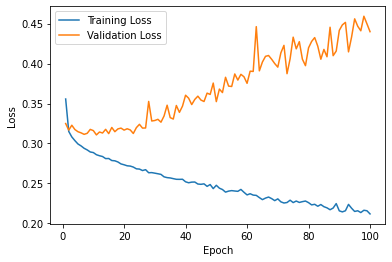

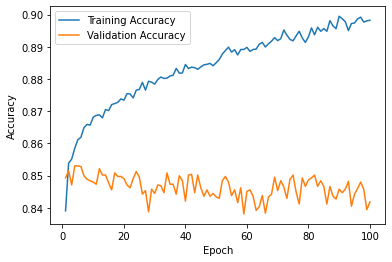

In [54]:
# Plot training loss and validation loss over epochs
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [66]:
#Might be overfitted

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [62]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

probability_predictions = nn_model.predict(X_test_scaled)
class_label_predictions_final=[]

for i in range(0,len(y_test)):
    if probability_predictions[i] >= 0.5:
        class_label_predictions_final.append(1)
    else:
        class_label_predictions_final.append(0)

In [63]:
# Compute accuracy and F1 score for the neural network and print the results

acc_score_neural = accuracy_score(y_test, class_label_predictions_final)
f1_score_neural = f1_score(y_test, class_label_predictions_final, average='binary')
print(acc_score_neural)
print(f1_score_neural)

0.8344764049544477
0.6243902439024389


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I chose 4 layers, (64, 32, 16, 8) units, I used ReLU and signmoid functions, learning rate of 0.1, and 100 num of epochs. I made each of the choices because I was seeking to see if the model's accuracy and F1 score will improve if I add more than 3 layers and a variety of units to getting the best possible weights and parameters. I chose my activation functions because they are best suited for classification ML problems which is what my model is seeking to solve. I chose the learning rate and epochs to be that certain amount because they are the default values to makign a strong model.
2. My training Curve tells me that the neural network model is overfitting. The training loss is decreasing but my accuracy scores is increasingly high, which is a big indicator of the neural network being overfitted. My validation loss is decreasing or steadly increasing. This could hint of the model memorizing the training data but doesn't generalize very well.
3. My neural network have a very strong accuracy score 83% on the test set, which is very good and is in the range we want to get for our model. The F1 score is 62%, I was hoping the F1 score will improve with neural networks but the socre is nearly identical with my decision tree model. I find this to be surprising. 

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [65]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))
#

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Decision Tree Model': [acc_score_best, f1_score_best],
    'Neural Network': [acc_score_neural, f1_score_neural] })
print(results.to_string(index=False))

   Metric  Decision Tree Model  Neural Network
 Accuracy             0.809807        0.834476
 F1 Score             0.615321        0.624390


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. The Neural Network model has performed better than the Decision Tree model across from all metrics: Accuracy and F1 scores. The DT model has a 81% accuracy and 61.5% F1 score but the Neural Network has a 83% accuracy and 62.4% F1 scores. The Neural Network performed better overall but not by a major margin. 
2. I think since NN model performed overall on everything, the NN is justified dispite it's complexity. I believe the NN model would perform even better if I further tune parameters, layers, units, and learning rate.
3. I would recommend the DT model because of it's simpler implementation and interpretabiity. I have have more ways of representing the model's performance through histoplots and bar charts, demonstrating the which features correlate with >50K the most. the company could take this in consideration and weigh more on the customer's age or education-num as eligibility requirements for their programs.
4. I would test with variant different parameters, units, layers, etc. Especially for the Neural Network I want to experienment with different values of the units and other parameters. DT trees have a feature "class_weights", which can balance classes. To fix class imbalance, I would remove even more features to balance out the class and perform more preprocessing steps. 

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used Google Gemini to remind me of Decision Trees and how to implement them as I forgot about them. I also asked AI if my ideas of removing certain features would be good to solve the ML problem better and it would give me suggestions or agree with my choices. Most of other times, I asked it about the syntax errors I get from my decision tree mode or NN model, which most of the time of wrong usage of some variables or small errors. I also asked Gemini for greater clarity of the visual graphs I produced to get a better understanding of them.

2. One part of the capstone that was the most challenging was cleaning up my data and preparing for my model. I have think about what features should I keep, filling out NaN values and identify outliers or class imbalances. This was challanging because I have more control in how I want to prepare my model and I was worried if I make the right or wrong choices. How I worked through them was referencing my past work in the eariler units, reminding myself of how to effectively clean and prepare for my model. I also have to think of a way of how I could balance my class, but Gemini told me of a parameter in DT Trees that solves the imbalances, which is class_weight='balance' I think this helps quite a bit with my model as the accuracy score is not to high, reducing the risk of overfitting. I also had to research about F1-scores and how to interpret them as I believe I didn't learning them in this course.

3. I verify my work is correct by seeing if my results matches up with prompts and instructions. I also checked by using the .head() method to see the data matrix. I look for any errors after running my cells from syntax or I research more documentations of the methods I used to catch any mistakes.

4. What I would do differently next time, I would reference the videos and readings again from other units to assist me with concepts. I would also brainstorm more before I write out my solutions. 